In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print('TensorFlow version:', tf.__version__)
print('Libraries ready!')

TensorFlow version: 2.21.0
Libraries ready!


In [46]:
df = pd.read_csv('Data/cleaned_retail.csv', parse_dates=['InvoiceDate'])

print('Shape:', df.shape)
df.head()

Shape: (779425, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalAmount,Month,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,Tuesday,7


In [47]:
# Aggregate total revenue per week
df['Week'] = df['InvoiceDate'].dt.to_period('W')
weekly_sales = df.groupby('Week')['TotalAmount'].sum().reset_index()
weekly_sales.columns = ['Week', 'Revenue']
weekly_sales['Week'] = weekly_sales['Week'].astype(str)

print('Weekly sales shape:', weekly_sales.shape)
weekly_sales.head(10)

Weekly sales shape: (104, 2)


,Week,Revenue
0,2009-11-30/2009-12-06,232177.510
1,2009-12-07/2009-12-13,207908.730
2,2009-12-14/2009-12-20,207685.870
3,2009-12-21/2009-12-27,35731.900
4,2010-01-04/2010-01-10,167636.950
5,2010-01-11/2010-01-17,125493.610
6,2010-01-18/2010-01-24,119473.351
7,2010-01-25/2010-01-31,143198.761
8,2010-02-01/2010-02-07,112299.692
9,2010-02-08/2010-02-14,80059.660


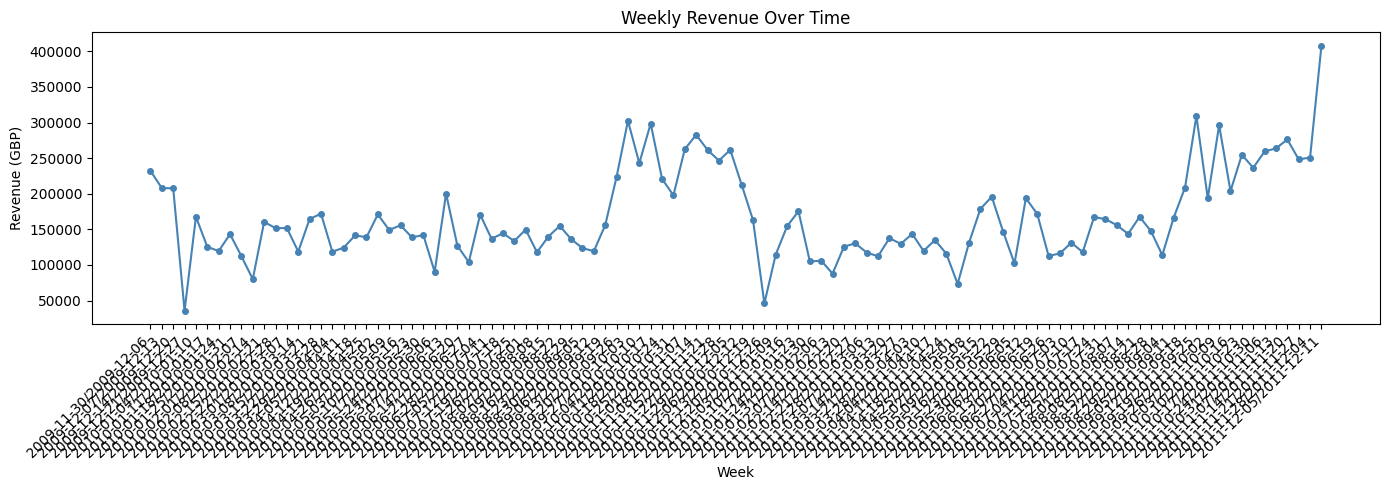

In [48]:
# Plot weekly sales
plt.figure(figsize=(14, 5))
plt.plot(weekly_sales['Week'], weekly_sales['Revenue'],
         marker='o', color='steelblue', linewidth=1.5, markersize=4)
plt.title('Weekly Revenue Over Time')
plt.xlabel('Week')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
# Scale the revenue values to range 0–1
scaler = MinMaxScaler()
revenue_scaled = scaler.fit_transform(weekly_sales[['Revenue']])

# Create sequences
# window_size = how many past weeks the model looks at
window_size = 4

X, y = [], []
for i in range(window_size, len(revenue_scaled)):
    X.append(revenue_scaled[i - window_size:i, 0])  # past 4 weeks
    y.append(revenue_scaled[i, 0])                  # next week

X = np.array(X)
y = np.array(y)

# Reshape X to (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (100, 4, 1)
y shape: (100,)


In [50]:
# Train / Test split (80% train, 20% test)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print('Train samples:', X_train.shape[0])
print('Test samples :', X_test.shape[0])

Train samples: 80
Test samples : 20


In [51]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)   # output: next week's revenue
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

print('Training done!')

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0762 - val_loss: 0.1267
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0241 - val_loss: 0.0301
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0190 - val_loss: 0.0327
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0157 - val_loss: 0.0526
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0161 - val_loss: 0.0406
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0160 - val_loss: 0.0366
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0145 - val_loss: 0.0419
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0134 - val_loss: 0.0381
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0150 - val_loss: 0.0402
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0157 - val_loss: 0.0340
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0147 - val_loss: 0.0372
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0144 - va

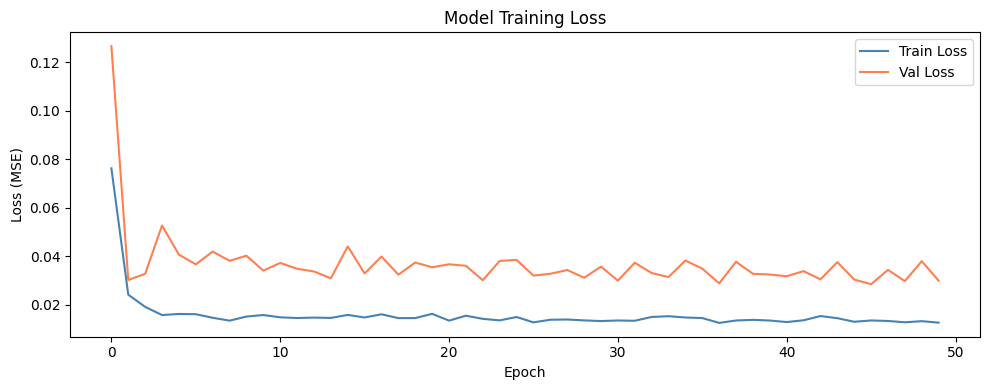

In [53]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='coral')
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# Make predictions
y_pred_scaled = model.predict(X_test)

# Reverse the scaling to get actual GBP values
y_pred_actual = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)

print(f'RMSE : £{rmse:,.2f}')
print(f'MAE  : £{mae:,.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
RMSE : £64,314.10
MAE  : £44,431.12


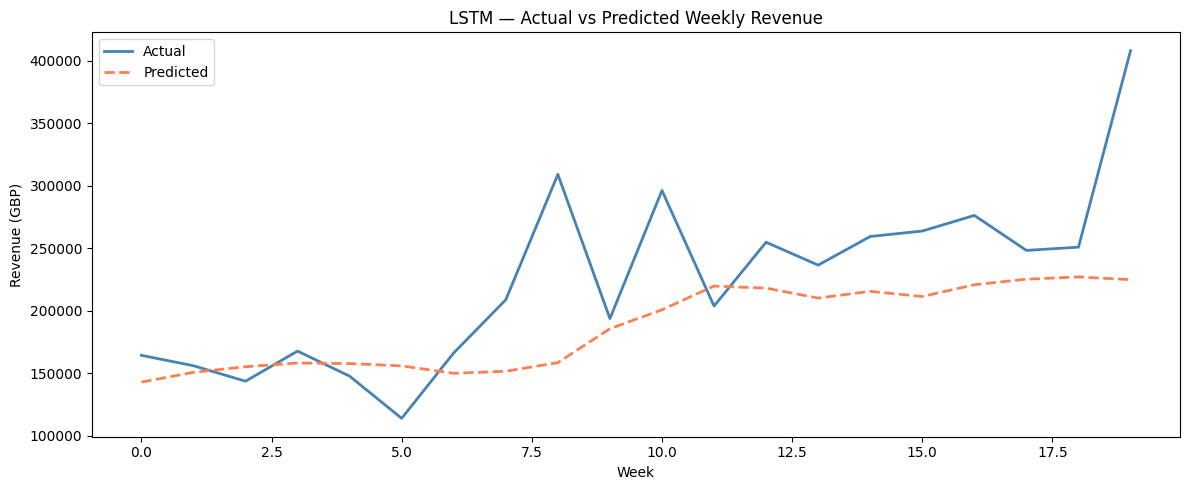

In [55]:
# Plot predictions vs actual
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual,  label='Actual',    color='steelblue', linewidth=2)
plt.plot(y_pred_actual,  label='Predicted', color='coral',     linewidth=2, linestyle='--')
plt.title('LSTM — Actual vs Predicted Weekly Revenue')
plt.xlabel('Week')
plt.ylabel('Revenue (GBP)')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
# Use last 4 weeks as input to predict next 4 weeks
last_sequence = revenue_scaled[-window_size:].reshape(1, window_size, 1)
future_preds  = []

for _ in range(4):
    next_val = model.predict(last_sequence, verbose=0)[0][0]
    future_preds.append(next_val)
    # Slide the window forward
    last_sequence = np.append(last_sequence[:, 1:, :],
                               [[[next_val]]], axis=1)

# Reverse scale
future_preds_actual = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
)

print('Forecasted Revenue for next 4 weeks:')
for i, val in enumerate(future_preds_actual, 1):
    print(f'  Week +{i}: £{val[0]:,.2f}')

Forecasted Revenue for next 4 weeks:
  Week +1: £250,347.53
  Week +2: £249,818.92
  Week +3: £247,034.88
  Week +4: £241,138.72


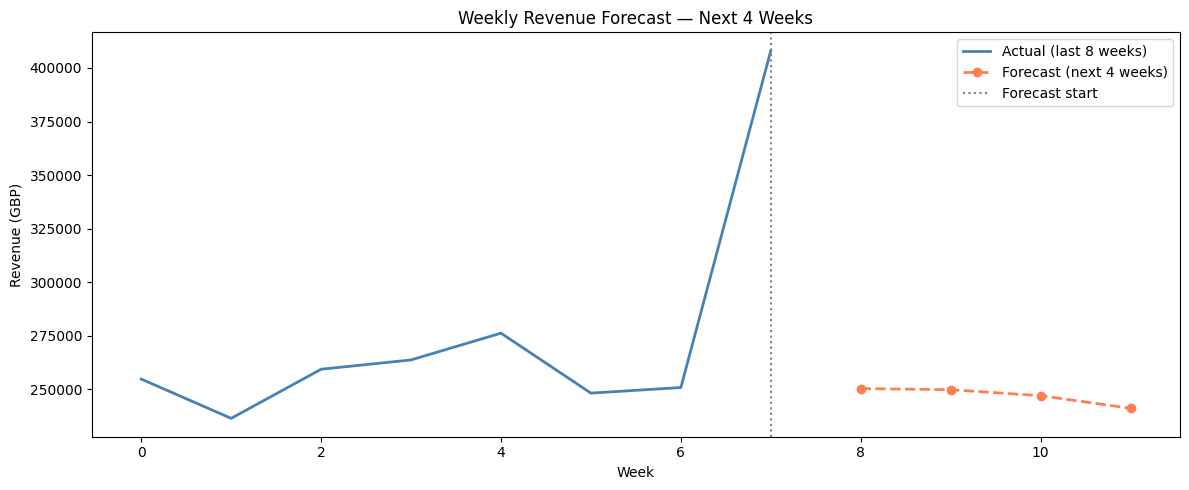

In [57]:
# Plot forecast
last_actual = y_test_actual[-8:]  # last 8 actual weeks

plt.figure(figsize=(12, 5))
plt.plot(range(len(last_actual)), last_actual,
         label='Actual (last 8 weeks)', color='steelblue', linewidth=2)
plt.plot(range(len(last_actual), len(last_actual) + 4),
         future_preds_actual,
         label='Forecast (next 4 weeks)', color='coral',
         linewidth=2, linestyle='--', marker='o')
plt.axvline(x=len(last_actual) - 1, color='gray', linestyle=':', label='Forecast start')
plt.title('Weekly Revenue Forecast — Next 4 Weeks')
plt.xlabel('Week')
plt.ylabel('Revenue (GBP)')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
model.save('Models/lstm_model.h5')
pickle.dump(scaler, open('Models/lstm_scaler.pkl', 'wb'))

# Save weekly sales for dashboard
weekly_sales.to_csv('Data/weekly_sales.csv', index=False)

print('LSTM model saved to Models/lstm_model.h5')
print('Weekly sales saved to Data/weekly_sales.csv')

LSTM model saved to Models/lstm_model.h5
Weekly sales saved to Data/weekly_sales.csv


In [59]:
# Top products by number of times purchased
popular_products = (
    df.groupby(['StockCode', 'Description'])['Invoice']
    .nunique()
    .reset_index()
    .rename(columns={'Invoice': 'PurchaseCount'})
    .sort_values('PurchaseCount', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print('Top 20 Popular Products:')
popular_products.head(10)

Top 20 Popular Products:


,StockCode,Description,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4888
1,22423,REGENCY CAKESTAND 3 TIER,3317
2,84879,ASSORTED COLOUR BIRD ORNAMENT,2652
3,85099B,JUMBO BAG RED RETROSPOT,2612
4,47566,PARTY BUNTING,2077
5,20727,LUNCH BAG BLACK SKULL.,1997
6,22382,LUNCH BAG SPACEBOY DESIGN,1874
7,21034,REX CASH+CARRY JUMBO SHOPPER,1857
8,21754,HOME BUILDING BLOCK WORD,1831
9,21232,STRAWBERRY CERAMIC TRINKET BOX,1818


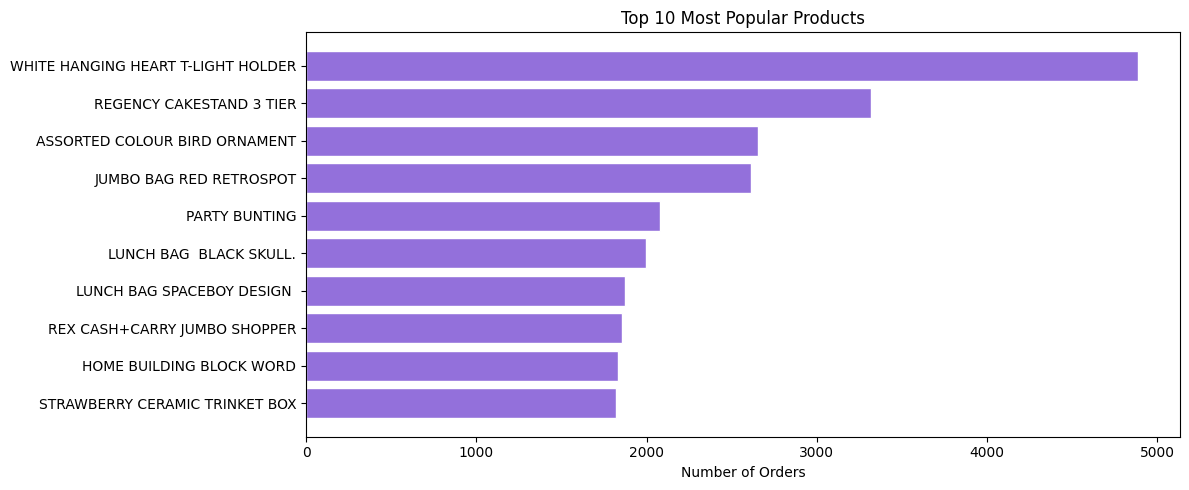

In [60]:
# Plot top 10 popular products
top10 = popular_products.head(10)

plt.figure(figsize=(12, 5))
plt.barh(top10['Description'][::-1], top10['PurchaseCount'][::-1],
         color='mediumpurple', edgecolor='white')
plt.title('Top 10 Most Popular Products')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

In [61]:
# Build a Customer x Product matrix
# Each cell = how many times customer bought that product
customer_product = df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().unstack(fill_value=0)

print('Customer-Product matrix shape:', customer_product.shape)
customer_product.head()

Customer-Product matrix shape: (5878, 4631)


StockCode,10002,10080,10109,10120,10123C,10123G,10124A,10124G,10125,10133,...,BANK CHARGES,C2,D,DOT,M,PADS,POST,SP1002,TEST001,TEST002
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,45,1
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,10,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [62]:
from sklearn.metrics.pairwise import cosine_similarity

# ── Rebuild matrix with named index/columns reset ──
customer_product = (
    df.groupby(['CustomerID', 'StockCode'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

# Reset index name to avoid any name conflicts
customer_product.index.name   = None
customer_product.columns.name = None

# Build similarity matrix using plain numpy array
sim_matrix = cosine_similarity(customer_product.values)

# Build DataFrame using a plain list of customer IDs
customer_ids = customer_product.index.tolist()

customer_sim_df = pd.DataFrame(
    sim_matrix,
    index=customer_ids,
    columns=customer_ids
)

print('Matrix shape    :', customer_product.shape)
print('Sim shape       :', customer_sim_df.shape)
print('Index unique    :', customer_sim_df.index.is_unique)
print('Columns unique  :', customer_sim_df.columns.is_unique)

Matrix shape    : (5878, 4631)
Sim shape       : (5878, 5878)
Index unique    : True
Columns unique  : True


In [63]:
def recommend_products(customer_id, n_recommendations=5):

    customer_id = int(customer_id)

    if customer_id not in customer_sim_df.index:
        print(f'Customer {customer_id} not found. Showing popular products.')
        return popular_products.head(n_recommendations)

    # Use iloc instead of loc to avoid index name issues
    idx = customer_ids.index(customer_id)
    sim_scores = pd.Series(
        sim_matrix[idx],
        index=customer_ids
    )

    # Remove the customer itself
    sim_scores = sim_scores.drop(index=customer_id, errors='ignore')

    # Top 5 most similar customers
    top_similar = sim_scores.sort_values(ascending=False).head(5).index.tolist()

    # Products this customer already bought
    already_bought = set(
        customer_product.iloc[idx][customer_product.iloc[idx] > 0].index.tolist()
    )

    # Sum purchases of similar customers
    similar_rows = customer_product.loc[top_similar]
    scores = similar_rows.sum()

    # Remove already bought products
    scores = scores.drop(index=list(already_bought), errors='ignore')
    scores = scores.sort_values(ascending=False).head(n_recommendations)

    # Map StockCode to product name
    product_map = (
        df[['StockCode', 'Description']]
        .drop_duplicates(subset=['StockCode'])
        .set_index('StockCode')['Description']
    )

    result = scores.reset_index()
    result.columns = ['StockCode', 'Score']
    result['Description'] = result['StockCode'].map(product_map)

    return result

In [64]:
sample_customer = int(df['CustomerID'].value_counts().index[0])
print(f'Recommendations for Customer {sample_customer}:\n')
recommend_products(sample_customer, n_recommendations=5)

Recommendations for Customer 17841:



,StockCode,Score,Description
0,22791,146,T-LIGHT GLASS FLUTED ANTIQUE
1,17084R,72,ASSORTED INCENSE PACK
2,21192,60,WHITE BELL HONEYCOMB PAPER
3,21191,50,LARGE WHITE HONEYCOMB PAPER BELL
4,84879,48,ASSORTED COLOUR BIRD ORNAMENT


In [65]:
recommend_products(12345, n_recommendations=5)

Customer 12345 not found. Showing popular products.


,StockCode,Description,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4888
1,22423,REGENCY CAKESTAND 3 TIER,3317
2,84879,ASSORTED COLOUR BIRD ORNAMENT,2652
3,85099B,JUMBO BAG RED RETROSPOT,2612
4,47566,PARTY BUNTING,2077


In [66]:
# Save popular products for dashboard
popular_products.to_csv('Data/popular_products.csv', index=False)

# Save customer-product matrix for dashboard
customer_product.to_csv('Data/customer_product_matrix.csv')

print('Saved popular_products.csv')
print('Saved customer_product_matrix.csv')

Saved popular_products.csv
Saved customer_product_matrix.csv
